In [1]:
# mlp for regression



In [2]:
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from matplotlib import pyplot
from tensorflow.keras.utils import plot_model
import seaborn as sns

2024-02-29 11:56:54.344912: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-02-29 11:56:54.365530: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-29 11:56:54.471784: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-29 11:56:54.471889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-29 11:56:54.490743: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [5]:
def balance_classes(df, column_name="Age"):
    """
    Balance the classes in a dataframe by downsampling the majority classes
    
    :param df: The dataframe to balance
    :param column_name: The name of the column to balance by

    :return: Tuple containing the balanced dataframe and the dataframe with unselected rows
    """
    df['group'] = pd.cut(df[column_name], bins=[-np.inf, 35, 65, np.inf], labels=[1, 2, 3], right=False)
    min_group_size = df['group'].value_counts().min()  # Calculate the size of the smallest group
    sample_size = min_group_size # + random.randint(-10, 10)  # Add some randomness to the sample size  Remove with stratification
    balanced_df = pd.DataFrame()
    unselected_df = pd.DataFrame()
    
    for value in [1, 2, 3]:
        subset = df[df['group'] == value]
        if len(subset) <= sample_size:
            balanced_df = pd.concat([balanced_df, subset])
        else:
            balanced_subset = subset.sample(sample_size)
            unselected_subset = subset.drop(balanced_subset.index)
            balanced_df = pd.concat([balanced_df, balanced_subset])
            unselected_df = pd.concat([unselected_df, unselected_subset])
    
    balanced_df = balanced_df.drop(columns=['group'])
    unselected_df = unselected_df.drop(columns=['group'])
    
    return balanced_df, unselected_df

In [6]:
def remove_non_numeric_columns(df: pd.DataFrame):
    """
    Remove non-numeric columns from a dataframe
    
    :param df: The dataframe to remove the columns from
    
    :return: The dataframe with the non-numeric columns removed
    """
    
    return df.select_dtypes(include=[np.number])

In [7]:
def divide_test_train_dataset(balanced_df: pd.DataFrame, unselected_samples_df: pd.DataFrame=None):
    """
    Divide the dataset into a training and a test set
    
    :return: The training and test sets
    """

    X = remove_non_numeric_columns(balanced_df)
    X = X.drop(columns=['Age'])
    z = balanced_df[['Sample','Experiment', 'Age', 'Sex', 'Status']]     
    y = balanced_df['Age']
    y_class = pd.cut(balanced_df['Age'], bins=[-np.inf, 35, 65, np.inf], labels=[1, 2, 3], right=False)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y_class) # equal value to the labels

    X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(X, y, z, test_size=0.2, random_state=42, shuffle=True, stratify=y_class)
   
    if unselected_samples_df is not None:
        un_X = remove_non_numeric_columns(unselected_samples_df) # unselected_samples_df
        un_y = unselected_samples_df['Age']
        y_test = pd.concat([y_test, un_y])
        X_test = pd.concat([X_test, un_X])
    return X_train, X_test, y_train, y_test, z_train, z_test

In [8]:
def normalize_train_data(X_train: pd.DataFrame):
    """
    Normalize the training data
    
    :param X_train: The training data
    """

    scaler = StandardScaler()
    normalize_X_train = scaler.fit_transform(X_train)
    return normalize_X_train, scaler


In [22]:
def train_data(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae'], epochs=1500):
    """
    Train the data
    
    :return: The trained model
    """
    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model
    new_model.add(Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dense(1))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)


    new_model_history= new_model.fit(X_train, y_train, epochs=epochs, batch_size=50, verbose=0, validation_split=0.1)
    return new_model, new_model_history

In [10]:
def train_data_simplifided(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae']):
    """
    Train the data
    
    :return: The trained model
    """
    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dropout(0.7))  # Adding dropout to reduce overfitting
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dense(1))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)


    new_model_history= new_model.fit(X_train, y_train, epochs=150, batch_size=50, verbose=0, validation_split=0.05, shuffle=True)
    # testing part is not integrated yet.
    return new_model, new_model_history

In [11]:
def print_loss(history):
    """
    Print the loss of the model
    
    :param history: The history of the model
    """
    pyplot.title('Learning Curves')
    pyplot.xlabel('Epoch')
    pyplot.ylabel('Cross Entropy')
    pyplot.plot(history.history['loss'], label='train')
    pyplot.plot(history.history['val_loss'], label='val')
    pyplot.legend()
    pyplot.show()

In [12]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate the model
    
    :param model: The model to evaluate
    :param X_test: The test data
    :param y_test: The test labels
    """
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    print('MAE: %.3f' % mae)
    print('Loss: %.3f' % loss)
    # Make predictions using the trained model
    predictions = model.predict(X_test)

    # If your target variable is a single numeric value (regression), you can use predictions directly
    # For example, if predictions is a 2D array, you can flatten it to a 1D array
    predictions_flat = np.ravel(predictions)


    results = pd.DataFrame(list(zip(y_test, predictions_flat)))
    results=results.set_axis(["Actual", "Predicted"], axis=1)


    
    return results
    

In [13]:
def plot_results(results: pd.DataFrame, labels: pd.DataFrame, print_label:str='Experiment'):
    """
    Plot the results
    """
    # Extract 'experiment' column from original data
    experiment_column = labels[print_label].values
    results['Experiment'] = experiment_column
    print(results)
    # Plot scatter plot with color according to 'Experiment' column in results DataFrame
    
    # Create scatter plot with hue='Experiment' to group by Experiment category
    sns.scatterplot(x='Actual', y='Predicted', hue='Experiment', data=results, palette='Set1', alpha=0.8, edgecolor='w')


    plt.legend()
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.gca().set_ylim(bottom=15, top=100)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()

    #results.plot(kind='scatter', x='Actual', y='Predicted', s=32, alpha=.8)
    #plt.gca().spines[['top', 'right',]].set_visible(False)
    #plt.gca().set_ylim(bottom=15, top=100)
    #plt.show()
    

In [14]:
def get_feature_importance(model, X_train):
    """
    Get the feature importance of the model
    
    :param model: The model to get the feature importance of
    :param X_train: The training data
    """
    # Fit the model to the Lasso regressor
    lasso = Lasso(alpha=0.1)
    lasso.fit(X_train, model.predict(X_train))
    
    # Get the feature importance
    feature_importance = SelectFromModel(lasso)
    feature_importance.fit(X_train, model.predict(X_train))
    
    return feature_importance.get_support()

In [15]:
def save_selected_genes(genes:list, file_name:str):

    with open(file_name, 'w') as file:
        for gene in genes:
            file.write(f'{gene}\n')


In [16]:
def get_results_statistics(results: pd.DataFrame):
    """
    Get the statistics of the results
    
    :param results: The results to get the statistics of
    """
    # Calculate the mean absolute error
    mae = np.mean(np.abs(results['Actual'] - results['Predicted']))
    
    # Calculate the mean squared error
    mse = np.mean((results['Actual'] - results['Predicted']) ** 2)

    # min and max
    min_value = results['Predicted'].min()
    max_value = results['Predicted'].max()

    print(f"mae: {mae}, mse: {mse}, min: {min_value}, max: {max_value}")
    

In [17]:
def feature_selection(X_train: pd.DataFrame, y_train: pd.DataFrame, X_test: pd.DataFrame):
    """
    Select the most important features
    
    :param df: The dataframe to select the features from

    """
    lasso = Lasso(alpha=0.1)  # Adjust the alpha parameter
    selector = SelectFromModel(lasso)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    return X_train_selected, X_test_selected, selector
    


In [24]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'

/tmp/ipykernel_509517/1386220433.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


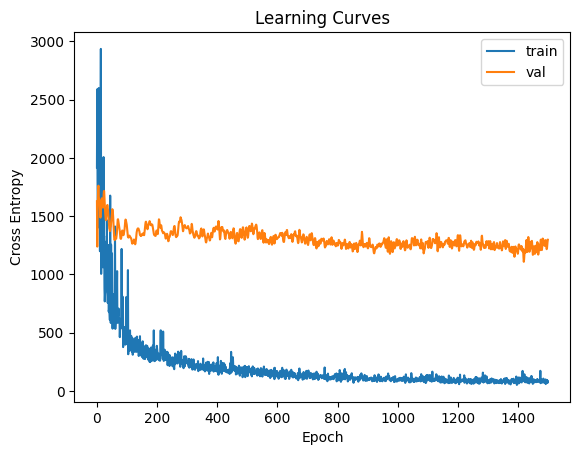

TypeError: evaluate_model() missing 1 required positional argument: 'original_data'

In [25]:
# load the dataset
df = pd.read_csv(dataset_path)
balanced_df, unselected_samples_df = balance_classes(df)
X_train, X_test, y_train, y_test = divide_test_train_dataset(balanced_df, unselected_samples_df)
normalize_X_train, scaler = normalize_train_data(X_train)
model, history = train_data(normalize_X_train, y_train)
print_loss(history)
results = evaluate_model(model, X_test, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)


MAE: 31919.123
Loss: 1228594432.000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


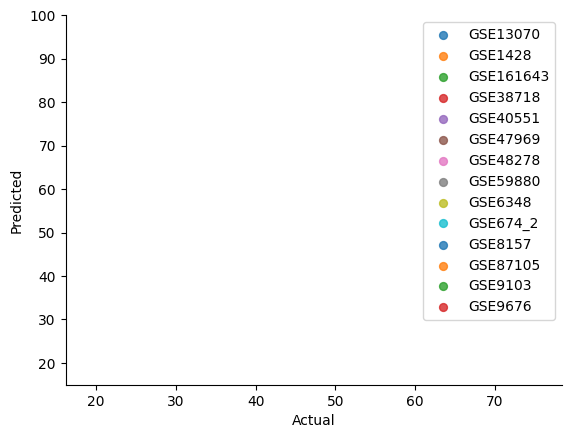

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Here I am training with the changes

In [54]:
df = pd.read_csv(dataset_path)
balanced_df, unselected_samples_df = balance_classes(df)
X_train, X_test, y_train, y_test = divide_test_train_dataset(df)
normalize_X_train, scaler = normalize_train_data(X_train)


/tmp/ipykernel_509517/2987588296.py:1: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)


In [56]:
normalize_X_train[:5]

array([[ 2.30920103e-01,  2.28534304e-01,  4.37169593e-01, ...,
         3.60971363e+00,  2.13870382e+00,  4.73360846e-01],
       [ 7.58108778e-01, -1.14833722e+00,  5.25634653e-01, ...,
         1.27711313e+00,  8.28195449e-01, -1.86242871e-01],
       [-1.46232428e-01,  3.13966351e-03, -1.60715735e-04, ...,
        -2.10808859e-02, -8.07760889e-03, -5.01465675e-01],
       [ 1.07368664e+00, -2.25218075e+00,  3.94042121e-01, ...,
         1.33741279e+00,  1.56653631e+00, -2.78445541e-01],
       [ 3.03818177e+00,  3.34310020e+00,  4.22019020e+00, ...,
        -2.18433812e-02, -9.05027747e-03,  1.79966079e+00]])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


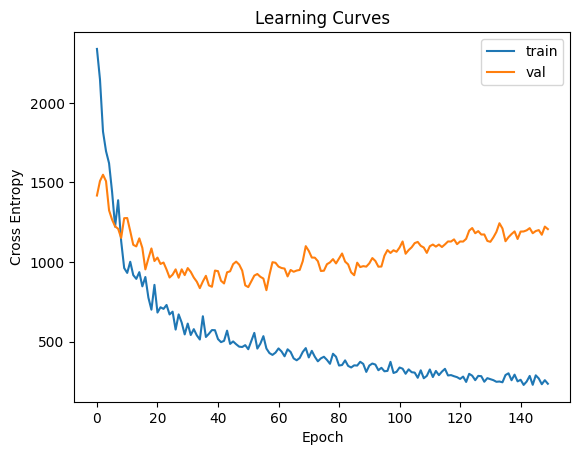

MAE: 33236.129
Loss: 1279792896.000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


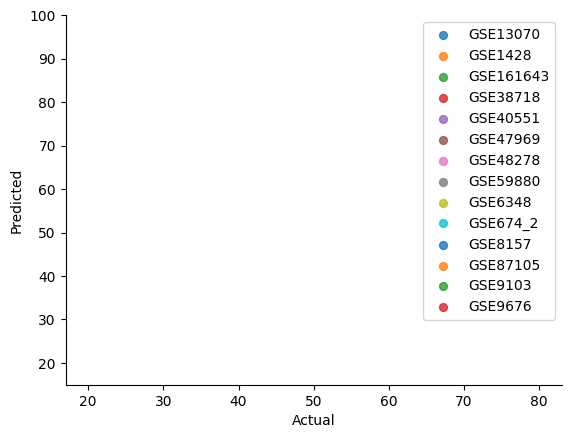

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
mae: 33236.131800881405, mse: 1280267022.6918428, min: 6115.5234375, max: 68119.984375


In [57]:
model, history = train_data_simplifided(normalize_X_train, y_train)
print_loss(history)
results = evaluate_model(model, X_test, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)

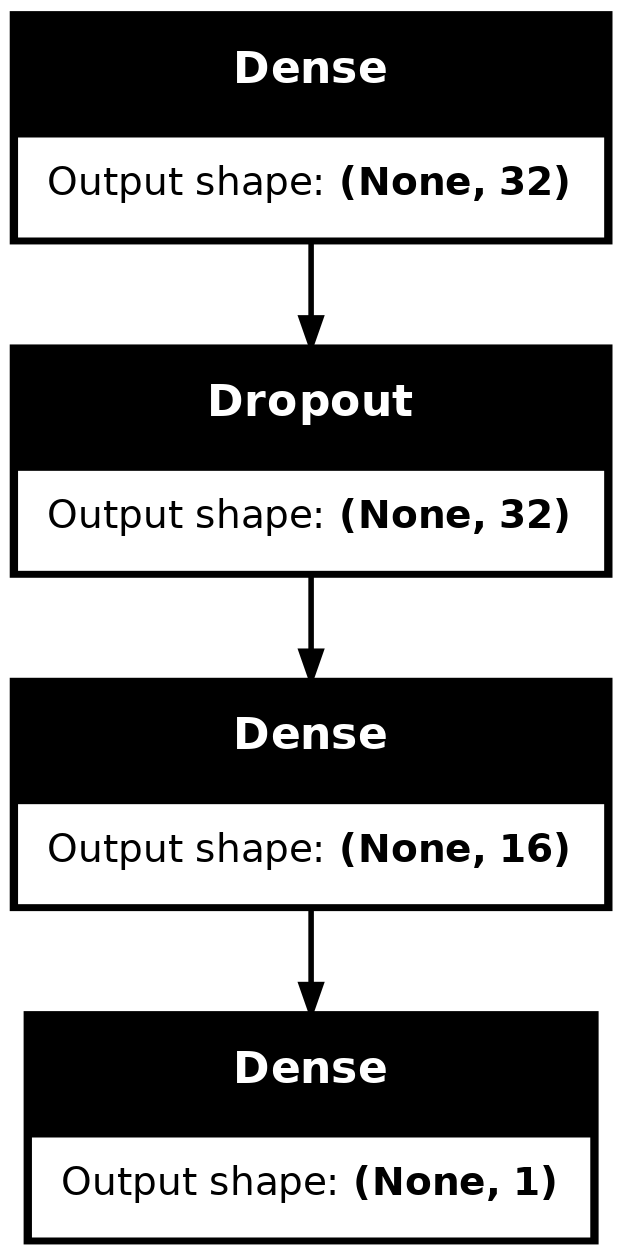

In [58]:
plot_model(model, 'model.png', show_shapes=True)


I will try again with the unadjusted data

/tmp/ipykernel_8306/1248001271.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(un_dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


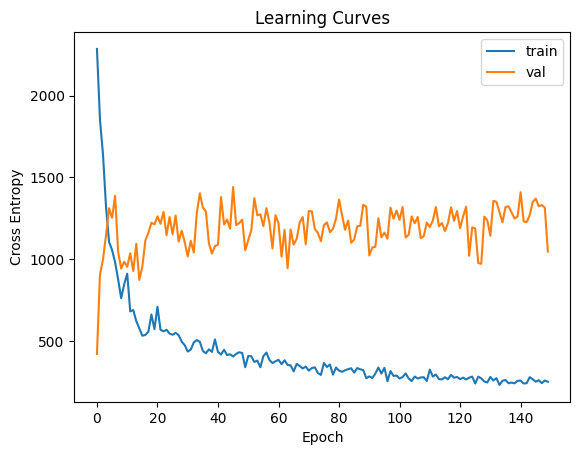

MAE: 11890.167
Loss: 264193200.000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
mae: 11890.166216970834, mse: 262610043.72148827, min: 2.517825126647949, max: 31243.94140625


In [20]:
un_dataset_path='Data/trainign_dataset_51270_microarray_unadjusted.csv'
df = pd.read_csv(un_dataset_path)
X_train, X_test, y_train, y_test, z_test, z_train = divide_test_train_dataset(df)
normalize_X_train, scaler = normalize_train_data(X_train)
model, history = train_data_simplifided(normalize_X_train, y_train)
print_loss(history)
results = evaluate_model(model, X_test, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)

Now with the more complex model

In [19]:
un_dataset_path='Data/trainign_dataset_51270_microarray_unadjusted.csv'
df = pd.read_csv(un_dataset_path)
X_train, X_test, y_train, y_test, _,_ = divide_test_train_dataset(df)
normalize_X_train, scaler = normalize_train_data(X_train)
model, history = train_data(normalize_X_train, y_train)
print_loss(history)
results = evaluate_model(model, X_test, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)

/tmp/ipykernel_8306/129973968.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(un_dataset_path)


ValueError: too many values to unpack (expected 4)

In [ ]:
plot_model(model, 'model.png', show_shapes=True)


In [63]:
X_train.shape

(621, 51277)

Now let's try feature selection first

/tmp/ipykernel_8306/3551842161.py:4: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.579e+01, tolerance: 9.999e+00
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


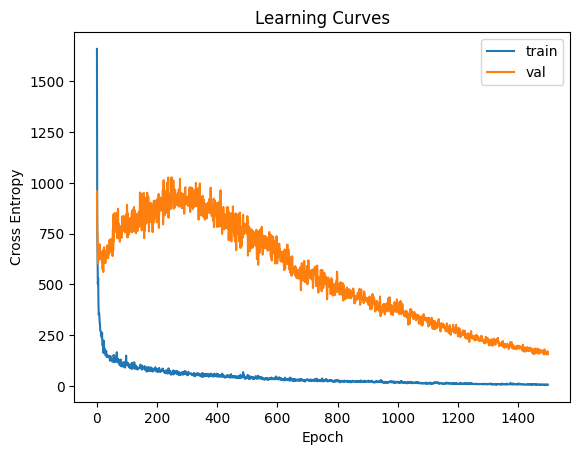

MAE: 10.430
Loss: 160.277
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
mae: 10.42955775236472, mse: 159.79772129643618, min: 23.529611587524414, max: 67.48817443847656


In [23]:
un_dataset_path='Data/trainign_dataset_51270_microarray_unadjusted.csv'
dataset_path='Data/trainign_dataset_51270_microarray_adjusted.csv'

df = pd.read_csv(dataset_path)

X_train, X_test, y_train, y_test, z_train, z_test = divide_test_train_dataset(df)
X_train_fs, X_test_fs, selector = feature_selection(X_train, y_train, X_test=X_test)

normalize_X_train, scaler = normalize_train_data(X_train_fs)
model, history = train_data(normalize_X_train, y_train)
print_loss(history)
X_test_fs = scaler.transform(X_test_fs)
results = evaluate_model(model, X_test_fs, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)



In [33]:
X_test.columns

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X55005',
       'X79510', 'M21121', 'J02843',
       ...
       'AI654857', 'W22117', 'AI028241', 'AI571298', 'AA149545', 'C18318',
       'AI219073', 'AI205180', 'AI363375', 'Age'],
      dtype='object', length=51277)

In [46]:
selected_indices = selector.get_support()
    
selected_features = X_train.columns[selected_indices]
selected_features

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X79510',
       'M21121', 'J02843', 'X75208',
       ...
       'AF044263', 'AF022991', 'U03271', 'AL109698', 'AF055000', 'M93651',
       'AB023208', 'AA436930', 'AA400206', 'H61826'],
      dtype='object', length=4460)

In [24]:
selected = selected_features[feature_importance]

NameError: name 'selected_features' is not defined

In [55]:
all =(df).columns.to_list()  # all columns
f"{len(selected)/len(all)*100}% of selected genes" # ratio of selected columns to all columns

'0.6201127123106024% of selected genes'

In [57]:
pd.DataFrame(selected).to_csv('final_selected_genes.csv', index=False)

In [58]:
pd.DataFrame(all).to_csv('all_genes.csv', index=False)

In [20]:
z_test[['Experiment']].value_counts()


Experiment
GSE13070      50
GSE47969      29
GSE48278      21
GSE9103       12
GSE6348        7
GSE38718       6
GSE9676        6
GSE59880       6
GSE1428        4
GSE87105       4
GSE8157        4
GSE161643      3
GSE674_2       3
GSE40551       1
Name: count, dtype: int64

     Actual  Predicted Experiment
0     51.43  35.667152   GSE13070
1     34.20  28.941050    GSE8157
2     47.00  29.141520   GSE13070
3     39.00  26.621748   GSE47969
4     25.69  25.057516    GSE9103
..      ...        ...        ...
151   61.00  32.501404   GSE47969
152   54.15  32.027100   GSE13070
153   51.68  30.673155   GSE13070
154   46.00  27.587107   GSE48278
155   68.00  24.127558   GSE47969

[156 rows x 3 columns]


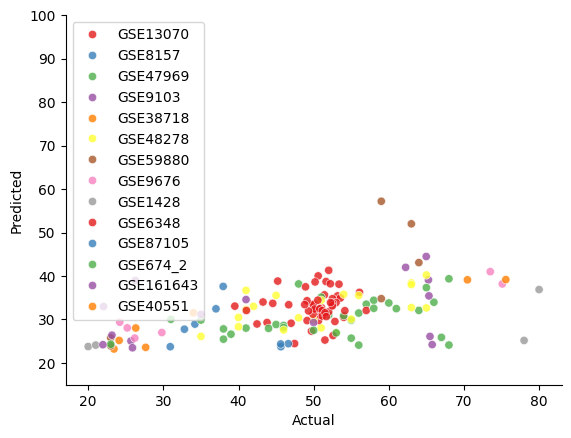

In [59]:
#evaluate_model(model, X_test_fs, y_test, df)

plot_results(results, z_test)

In [38]:
evaluate_model(model, X_test_fs, y_test, z_test)

MAE: 10.430
Loss: 160.277
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Actual,Predicted
0,51.43,45.883362
1,34.20,45.832718
2,47.00,38.147751
3,39.00,37.943451
4,25.69,28.054056
...,...,...
151,61.00,44.538940
152,54.15,42.347450
153,51.68,40.134834
154,46.00,39.755623


In [39]:
evaluate_model(model, X_test_fs, y_test, df)

MAE: 10.430
Loss: 160.277
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,Actual,Predicted
0,51.43,45.883362
1,34.20,45.832718
2,47.00,38.147751
3,39.00,37.943451
4,25.69,28.054056
...,...,...
151,61.00,44.538940
152,54.15,42.347450
153,51.68,40.134834
154,46.00,39.755623


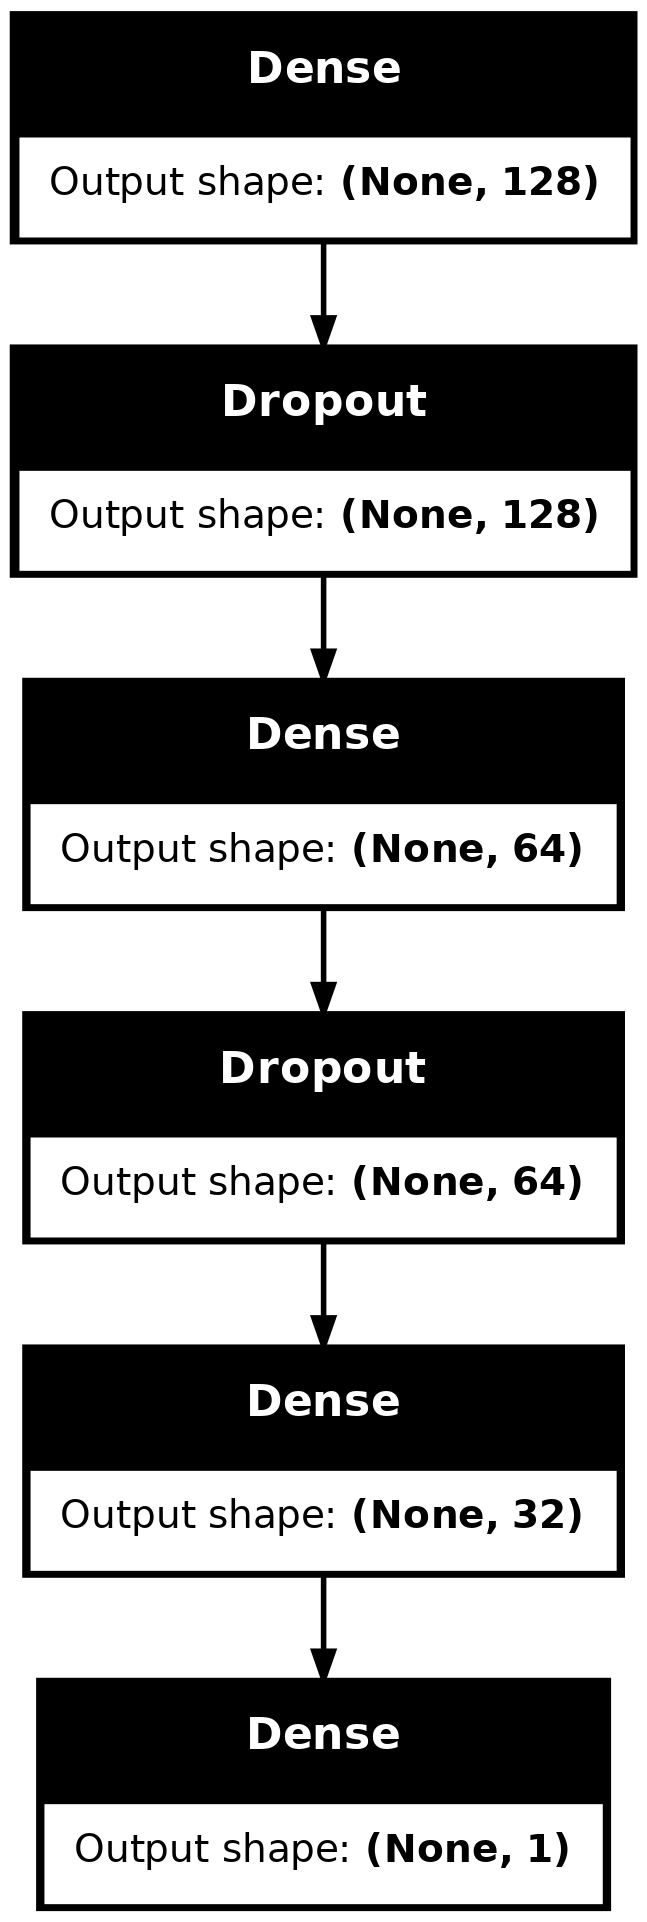

In [22]:
plot_model(model, 'model_complez.png', show_shapes=True)

MAE: 4.899
Loss: 40.398
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step
     Actual  Predicted Experiment
0     54.37  48.609779   GSE13070
1     46.00  44.418953   GSE47969
2     42.00  40.536057   GSE40551
3     44.83  43.856392   GSE13070
4     71.20  56.627235    GSE9676
..      ...        ...        ...
616   28.00  32.806046   GSE59880
617   76.09  58.695686   GSE87105
618   41.00  39.384655   GSE48278
619   53.00  47.947380   GSE48278
620   52.49  47.725452   GSE13070

[621 rows x 3 columns]


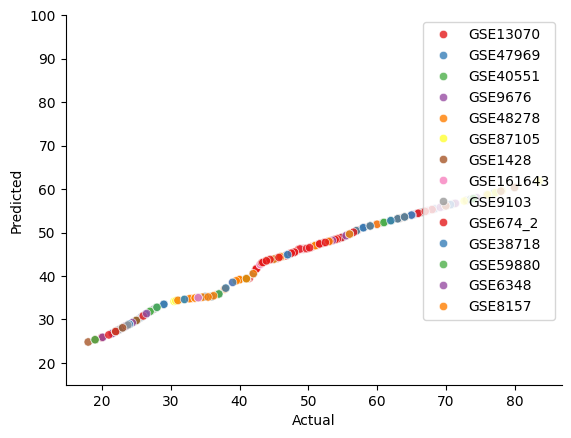

In [26]:
# Fake results just to see
X_train_fs = scaler.transform(X_train_fs)
fake_results = evaluate_model(model, X_train_fs, y_train, df)
plot_results(fake_results, z_train)


In [25]:
# let's look the genes
selected_feature_indices = selector.get_support()

# Get the names of the selected features
features = list(selected_feature_indices)


In [49]:
len(features)

51277

In [27]:
all_genes =  df.drop(['Age', 'Experiment', 'Sex', "Status"], axis=1).set_index('Sample', inplace=False).columns
selected_genes = all_genes[features]
selected_genes[:10]

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X79510',
       'M21121', 'J02843', 'X75208'],
      dtype='object')

In [34]:
selected_genes[feature_importance]

Index(['NM_080655', 'NM_173596', 'NM_014621', 'NM_032433', 'NM_173549',
       'NM_152610', 'NM_138337', 'NM_145696', 'NM_152335', 'NM_153007',
       ...
       'AW008502', 'AA541622', 'AI701408', 'AI341648', 'AI805301', 'BE549909',
       'AW590850', 'AI797017', 'H98113', 'AK000162'],
      dtype='object', length=397)

In [32]:
type(selected_genes)

pandas.core.indexes.base.Index

In [28]:
len(selected_genes)

4460

In [36]:
predictions = model.predict(X_test)

# If your target variable is a single numeric value (regression), you can use predictions directly
# For example, if predictions is a 2D array, you can flatten it to a 1D array
predictions_flat = np.ravel(predictions)
predictions_flat

InvalidArgumentError: Graph execution error:

Detected at node sequential_2_1/dense_7_1/Relu defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  F

Let's do adjusted one with the simplified version, feature selection and everything

In [ ]:
dataset_path='Data/trainign_dataset_51270_microarray_adjusted.csv'
df = pd.read_csv(dataset_path)
X_train, X_test, y_train, y_test, z_train, z_test = divide_test_train_dataset(df)
X_train_fs, X_test_fs, selector = feature_selection(X_train, y_train, X_test=X_test)

normalize_X_train, scaler = normalize_train_data(X_train_fs)
model, history = train_data(normalize_X_train, y_train)
print_loss(history)
X_test_fs = scaler.transform(X_test_fs)
results = evaluate_model(model, X_test_fs, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)

In [77]:
z_test

,Experiment,Age,Sex,Status
197,GSE13070,51.43,Male,IRd
678,GSE8157,34.20,Female,nPOS
98,GSE13070,47.00,Male,IRd
386,GSE47969,39.00,Male,NaN
741,GSE9103,25.69,Male,Trained
...,...,...,...,...
471,GSE47969,61.00,Male,NaN
147,GSE13070,54.15,Male,IRd
14,GSE13070,51.68,Male,IRd � TZD
576,GSE48278,46.00,Male,exercise group: D (Moderate aerobic exercise)


This a prevous intent with the adjsuted data, if re run, does nothing 

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


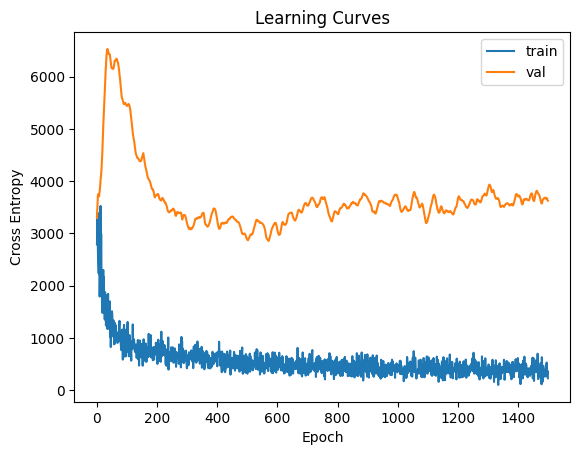

MAE: 6144.488
Loss: 55693284.000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


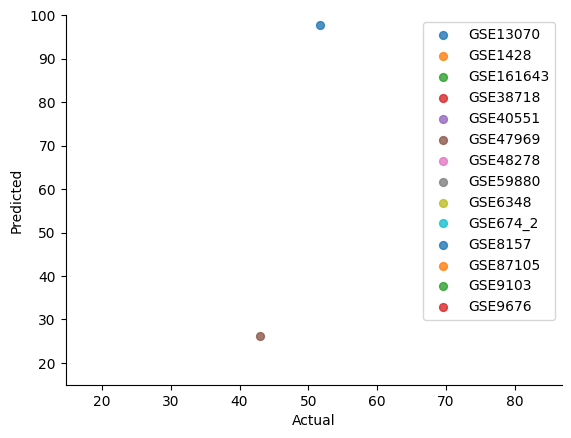

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
mae: 6144.488287164143, mse: 56022049.41426588, min: -27049.951171875, max: 12446.9140625


In [34]:
model, history = train_data_simplifided(normalize_X_train, y_train)
print_loss(history)
results = evaluate_model(model, X_test, y_test, df)
feature_importance = get_feature_importance(model, normalize_X_train)
get_results_statistics(results)

In [41]:
X_train.shape

(91, 51277)

MAE: 6753.429
Loss: 98767576.000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


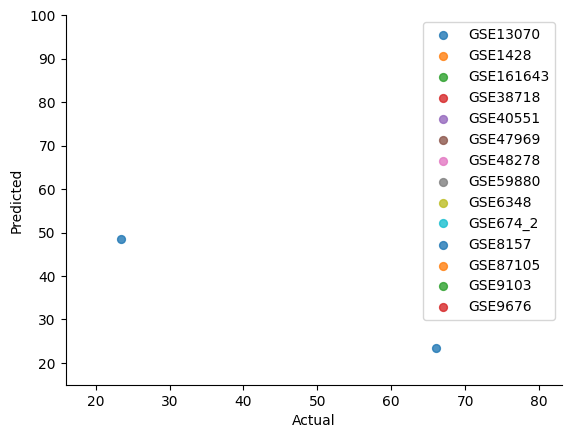

mae: 6753.429177631021, mse: 97983685.89625695, min: -45719.109375, max: 35530.0


In [33]:
results = evaluate_model(model, X_train, y_train, df)
get_results_statistics(results)

In [20]:
selected = (remove_non_numeric_columns(balanced_df).columns[feature_importance]).to_list()
all =(balanced_df).columns.to_list()  # all columns
f"{len(selected)/len(all)*100}% of selected genes" # ratio of selected columns to all columns

'0.12285251847662876% of selected genes'

MAE: 16451.375
Loss: 417813312.000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


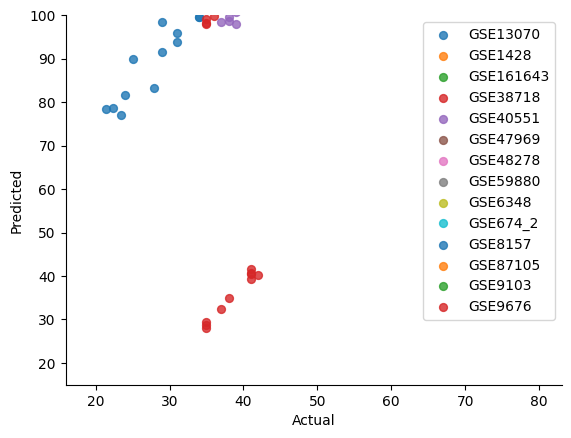

In [23]:
results = evaluate_model(model, X_test, y_test, df)

In [ ]:
plt.hist(sampled_df["Age"], bins=20)

In [ ]:

# split into input and output columns
X = normalize_sampled_df
y = sampled_df['Age'].values

# remove rows with all missing values
mask = np.isnan(X).all(axis=1)
X= X[~mask]
y= y[~mask]



In [ ]:
type(y)

In [ ]:
len(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
#X_train = np.asarray(X_train).astype(np.float32)
#y_train = np.asarray(y_train).astype(np.float32)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

In [ ]:
lasso = Lasso(alpha=0.1)  # Adjust the alpha parameter
selector = SelectFromModel(lasso)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [ ]:
selected_feature_indices = selector.get_support()

# Get the names of the selected features
features = list(selected_feature_indices)
all_genes =  sampled_df.drop(['Age', 'Experiment', 'Sex', "Status"], axis=1).set_index('Sample', inplace=False).columns
selected_genes = all_genes[features]
selected_genes[:10]

In [ ]:
len(features)

In [ ]:
len(normalize_sampled_df[0])

In [ ]:
all_genes =  sampled_df.drop(['Age', 'Experiment', 'Sex', "Status"], axis=1).set_index('Sample', inplace=False).columns
selected_genes = all_genes[features]
selected_genes[:10]

In [ ]:
filtered_df = sampled_df[selected_genes]

In [ ]:
filtered_df.columns

In [ ]:
X = filtered_df

# remove rows with all missing values
mask = np.isnan(X).all(axis=1)
X= X[~mask]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
#X_train = np.asarray(X_train).astype(np.float32)
#y_train = np.asarray(y_train).astype(np.float32)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

In [ ]:
y_train[0:10]

In [ ]:
len(X)

In [ ]:
X_train

In [ ]:
from tensorflow.keras.layers import Layer


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

In [ ]:
# determine the number of input features
n_features = X_train.shape[1]
# define model
loss = tf.keras.losses.Poisson()
# normalization + loss funtion + cross valitation
model = Sequential()
in_shape = X_train.shape[1:]
model.add(Dense(64, activation='relu', kernel_initializer='random_normal', input_shape=(n_features,)))
#model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='he_uniform', input_shape=in_shape))
model.add(Dense(8, activation='relu', kernel_initializer='he_normal'))
#model.add(Dense(2, activation='sigmoid', kernel_initializer='he_normal'))
model.add(Dense(1))
# compile the model
# change loss funtion
from tensorflow.keras.optimizers import SGD
sgd = SGD(learning_rate=0.001, momentum=0.8)
model.compile(optimizer='adam', loss='binary_crossentropy')
#model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#model.compile(optimizer='adam', loss=loss)

# fit the model
fitted_one = model.fit(X_train, y_train, epochs=1500, batch_size=15, verbose=0)


In [ ]:
#model.add(Layer.

In [ ]:


## add cross valitation

In [ ]:
model.summary()

In [ ]:
plot_model(model, 'model.png', show_shapes=True)

In [ ]:
X_train.shape

In [ ]:
error = model.evaluate(X, y, verbose=0)
#print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
error

In [ ]:
# evaluate the model
error = model.evaluate(X_test, y_test, verbose=0)
#print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
error
# make a prediction


In [ ]:
X_new = X_test
y_new= y_test
# Make predictions using the trained model
predictions = model.predict(X_new)

# If your target variable is a single numeric value (regression), you can use predictions directly
# For example, if predictions is a 2D array, you can flatten it to a 1D array
predictions_flat = np.ravel(predictions)



In [ ]:
X_new

In [ ]:
results = pd.DataFrame(list(zip(y_new, predictions_flat)))
results=results.set_axis(["Actual", "Predicted"], axis=1)

results

In [ ]:
from matplotlib import pyplot as plt
results.plot(kind='scatter', x='Actual', y='Predicted', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)

plt.show()

In [ ]:
np.max(results["Predicted"])

Lets try with the prune... please works :c

In [ ]:
# Evaluate the original model
_, accuracy_original = model.evaluate(X_test, y_test)
print(f'Accuracy of the original model: {accuracy_original}')

In [ ]:
history = model.fit(X, y, epochs=15000, batch_size=30, verbose=0, validation_split=0.3)
# plot learning curves
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

In [ ]:
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(fitted_one.history['loss'], label='train')
pyplot.plot(fitted_one.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

Let's try with another model


In [ ]:
new_model = Sequential()

# Add layers to the model
new_model.add(Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
new_model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
new_model.add(Dense(1))

# Compile the model
new_model.compile(optimizer='adam', loss='mse', metrics=['mae'])


new_model_history= new_model.fit(X_train, y_train, epochs=1500, batch_size=100, verbose=0, validation_split=0.1)

In [ ]:
pyplot.title('Learning Curves')
pyplot.xlabel('Epoch')
pyplot.ylabel('Cross Entropy')
pyplot.plot(new_model_history.history['loss'], label='train')
pyplot.plot(new_model_history.history['val_loss'], label='val')
pyplot.legend()
pyplot.show()

In [ ]:
X_new = X_test
y_new= y_test
# Make predictions using the trained model
predictions = new_model.predict(X_new)

# If your target variable is a single numeric value (regression), you can use predictions directly
# For example, if predictions is a 2D array, you can flatten it to a 1D array
predictions_flat = np.ravel(predictions)


results = pd.DataFrame(list(zip(y_new, predictions_flat)))
results=results.set_axis(["Actual", "Predicted"], axis=1)

results.plot(kind='scatter', x='Actual', y='Predicted', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)

plt.show()

In [ ]:
error = model.evaluate(X_test, y_test, verbose=0)
#print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
error

In [ ]:
np.max(results["Predicted"])

In [ ]:
np.min(results["Predicted"])